In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [2]:
pd.__version__

'2.2.3'

In [3]:
np.__version__

'2.2.4'

In [ ]:
#!pip install jupyter-black

In [2]:
%load_ext jupyter_black

In [3]:
df = pd.read_csv("../../data/intermediate/data_concat.csv", header=0)

/tmp/ipykernel_22578/2374769283.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../data/intermediate/data_concat.csv", header=0)


In [5]:
def df_initial_preproc(df):
    df.month = pd.to_datetime(df.month)
    df["year_of_sales"] = df["month"].dt.year
    df["month_of_sales"] = df["month"].dt.month
    # Clean up the 'MULTI-GENERATION' entries
    df["flat_type"] = df["flat_type"].str.replace(
        "MULTI GENERATION", "MULTI-GENERATION"
    )
    # add price per sqm
    df["price_per_sqm"] = df.resale_price / df.floor_area_sqm
    return df

# Price Per Square meter

In [7]:
# price per sqm across different town
def plot_sqm_all_town(df):
    df_initial_preproc(df)
    sns.set_style("whitegrid")
    sns.set_palette("bright")
    g = sns.catplot(
        data=df,
        x="price_per_sqm",
        y="town",
        kind="bar",
        height=7,
        aspect=1,
        errorbar=None,
    )
    g.fig.suptitle("Price Per Square Meter across different town", y=1.02, fontsize=15)
    g.set(xlabel="Town", ylabel="Price Per Square Meter")

    g.ax.set_xlabel(
        g.ax.get_xlabel(), fontsize=14
    )  # Access and set x-axis label font size

    g.ax.set_ylabel(
        g.ax.get_ylabel(), fontsize=14
    )  # Access and set y-axis label font size

    plt.xticks(rotation=0)
    plt.show()

<Figure size 640x480 with 0 Axes>

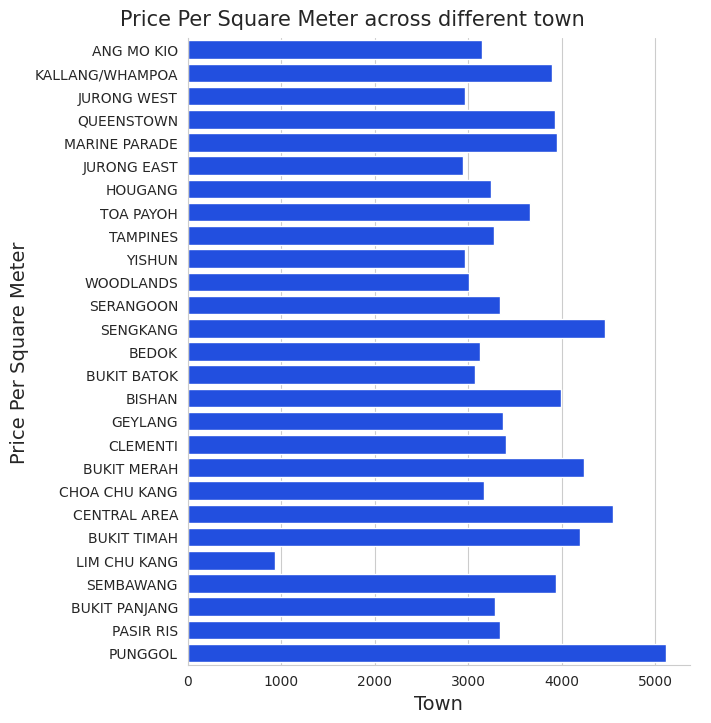

In [8]:
plt.clf()
plot_sqm_all_town(df)

In [9]:
# price per sqm across single town and flat type
def plot_sqm_single_twn_room(df, room, twn):
    df_initial_preproc(df)
    df_query = df.query("flat_type == @room & town == @twn")
    sns.set_style("whitegrid")
    sns.set_palette("bright")

    g = sns.catplot(
        data=df_query,
        x="year_of_sales",
        y="price_per_sqm",
        kind="bar",
        height=5,
        aspect=2.5,
        errorbar=None,
    )
    g.fig.suptitle(
        f"Price Per Square Meter across {twn} and flat type: {room}",
        y=1.01,
        fontsize=18,
    )
    g.set(xlabel="Year of sales", ylabel="Price Per Square Meter")
    g.ax.set_xlabel(
        g.ax.get_xlabel(), fontsize=16
    )  # Access and set x-axis label font size

    g.ax.set_ylabel(
        g.ax.get_ylabel(), fontsize=16
    )  # Access and set y-axis label font size
    plt.xticks(rotation=45)

    # Format the y-axis tick labels to include commas using a lambda function
    formatter = mtick.FuncFormatter(lambda x, pos: f"{int(x):,}")
    g.ax.yaxis.set_major_formatter(formatter)

    plt.show()

<Figure size 640x480 with 0 Axes>

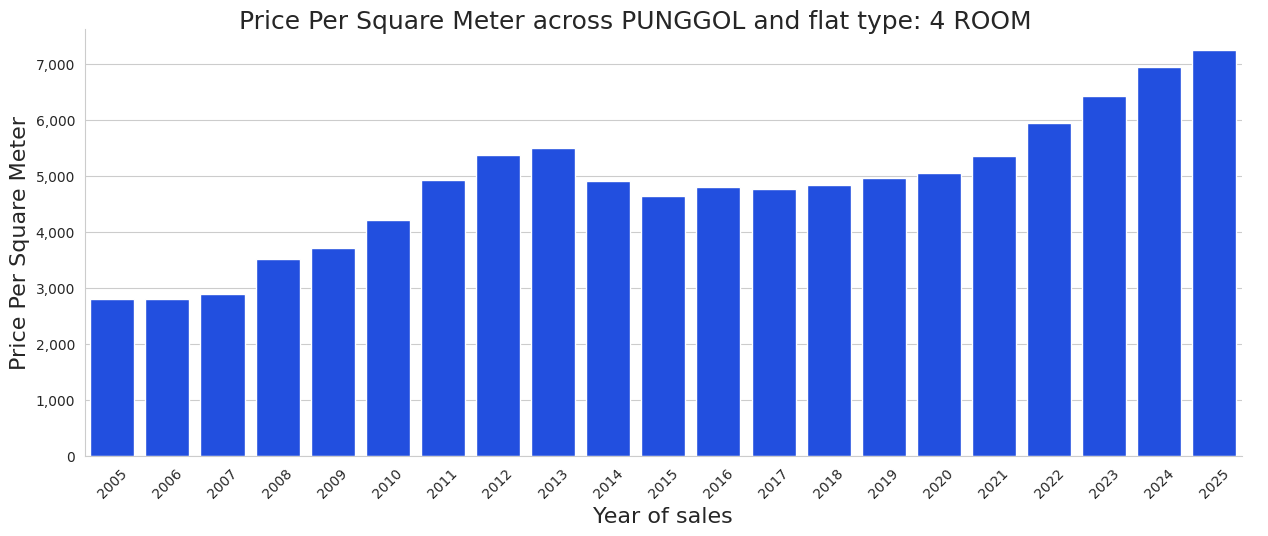

In [10]:
plt.clf()
plot_sqm_single_twn_room(df, "4 ROOM", "PUNGGOL")

## Resale price vs Town and flat type

In [11]:
import matplotlib.ticker as mtick

In [12]:
# mean resale price across different town
def plot_resale_price_all(df):
    df_initial_preproc(df)
    sns.set_style("whitegrid")
    sns.set_palette("bright")

    # Calculate the mean resale price for each town
    mean_prices = df.groupby("town")["resale_price"].mean().sort_values()

    # Create a new categorical order based on the sorted mean prices
    town_order = mean_prices.index.tolist()

    g = sns.catplot(
        data=df,
        x="town",
        y="resale_price",
        kind="bar",
        height=5,
        aspect=2.5,
        errorbar=None,
        order=town_order,
    )
    g.fig.suptitle("Mean Resale Price across different town", y=1.01, fontsize=16)
    g.set(xlabel="Town", ylabel="Resale Price")
    g.ax.set_xlabel(
        g.ax.get_xlabel(), fontsize=15
    )  # Access and set x-axis label font size

    g.ax.set_ylabel(
        g.ax.get_ylabel(), fontsize=15
    )  # Access and set y-axis label font size
    plt.xticks(rotation=90)

    # Format the y-axis tick labels to include commas using a lambda function
    formatter = mtick.FuncFormatter(lambda x, pos: f"{int(x):,}")
    g.ax.yaxis.set_major_formatter(formatter)

    plt.show()

<Figure size 640x480 with 0 Axes>

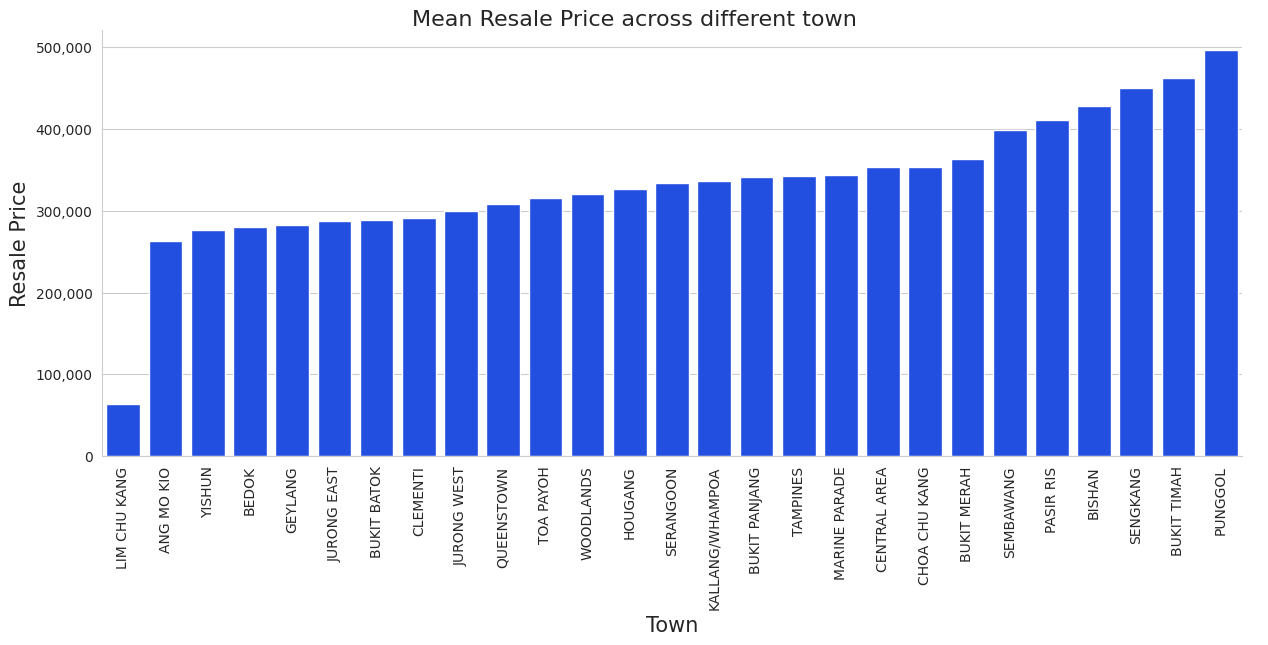

In [13]:
plt.clf()
plot_resale_price_all(df)

In [7]:
# mean resale price across single town and different flat type
def plot_resale_price_single(twn):
    df_initial_preproc(df)
    df_query = df.query("town == @twn")
    plt.clf()
    sns.set_style("whitegrid")
    sns.set_palette("bright")
    hue_order = [
        "1 ROOM",
        "2 ROOM",
        "3 ROOM",
        "4 ROOM",
        "5 ROOM",
        "EXECUTIVE",
        "MULTI-GENERATION",
    ]
    g = sns.catplot(
        data=df_query,
        x="town",
        y="resale_price",
        kind="bar",
        height=5,
        aspect=2,
        errorbar=None,
        hue="flat_type",
        hue_order=hue_order,
        palette="bright",
    )
    g.fig.suptitle(
        f"Mean Resale Price across {twn} and different flat type", y=1.01, fontsize=16
    )
    g.set(xlabel="Town", ylabel="Resale Price")

    g.ax.set_xlabel(
        g.ax.get_xlabel(), fontsize=15
    )  # Access and set x-axis label font size

    g.ax.set_ylabel(
        g.ax.get_ylabel(), fontsize=15
    )  # Access and set y-axis label font size

    plt.xticks(rotation=0)

    # Format the y-axis tick labels to include commas using a lambda function
    formatter = mtick.FuncFormatter(lambda x, pos: f"{int(x):,}")
    g.ax.yaxis.set_major_formatter(formatter)

    plt.show()

<Figure size 640x480 with 0 Axes>

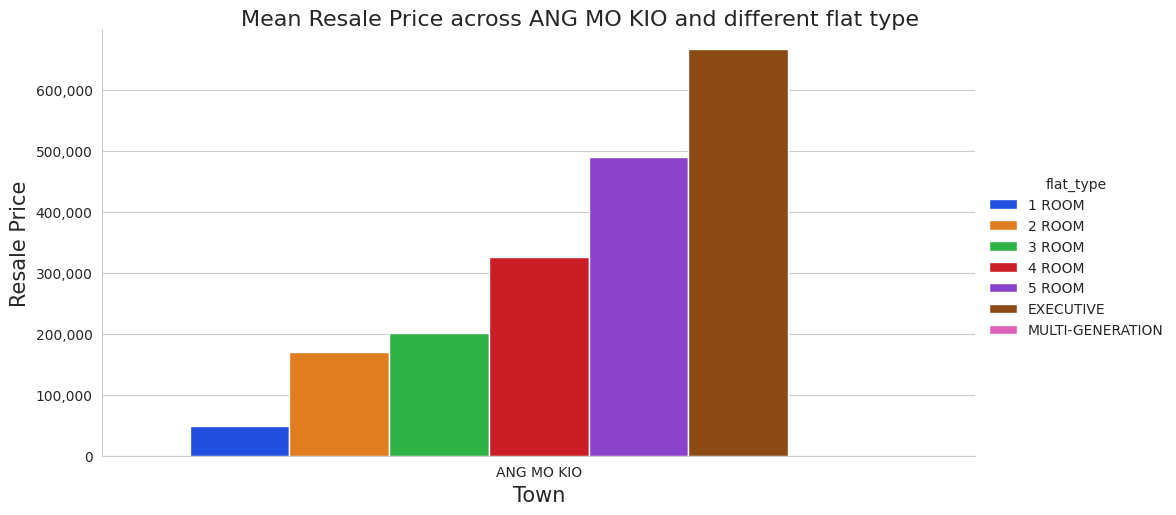

In [8]:
plt.clf()
plot_resale_price_single("ANG MO KIO")

In [49]:
def data_resale_price_single(df, room, twn):
    df_initial_preproc(df)
    df_query = df.query("flat_type == @room & town == @twn")
    price_summary_series = df_query["resale_price"].agg(["max", "min", "mean"])
    # Convert the Series to a DataFrame
    price_summary_df = (
        (
            price_summary_series.to_frame(
                name=f"Resale price summary of {twn}, {room} flat"
            )
        )
        .round()
        .astype(int)
    )

    # Apply the formatting to the column
    price_summary_df[price_summary_df.columns[0]] = price_summary_df[
        price_summary_df.columns[0]
    ].apply(lambda x: "{:,}".format(x))

    return price_summary_df

In [50]:
data_resale_price_single(df, "4 ROOM", "PUNGGOL")

,"Resale price summary of PUNGGOL, 4 ROOM flat"
max,"808,000"
min,"210,000"
mean,"493,522"


## Resale Price VS month

In [24]:
# mean resale price per month across all town
def plot_pricePerMonth_all(df):
    df_initial_preproc(df)
    sns.set_style("ticks")
    sns.set_palette("bright")
    # hue_order = ["1 ROOM", "2 ROOM", "3 ROOM", "4 ROOM", "5 ROOM","EXECUTIVE", "MULTI-GENERATION"]
    g = sns.catplot(
        data=df,
        x="month_of_sales",
        y="resale_price",
        kind="bar",
        height=5,
        aspect=2,
        errorbar=None,
    )
    g.fig.suptitle(
        "Mean resale Price per month across different town and flat type",
        y=1.01,
        fontsize=16,
    )
    g.set(xlabel="Month of Sales", ylabel="Resale Price")

    g.ax.set_xlabel(
        g.ax.get_xlabel(), fontsize=15
    )  # Access and set x-axis label font size

    g.ax.set_ylabel(
        g.ax.get_ylabel(), fontsize=15
    )  # Access and set y-axis label font size

    # Format the y-axis tick labels to include commas using a lambda function
    formatter = mtick.FuncFormatter(lambda x, pos: f"{int(x):,}")
    g.ax.yaxis.set_major_formatter(formatter)

    plt.show()

<Figure size 640x480 with 0 Axes>

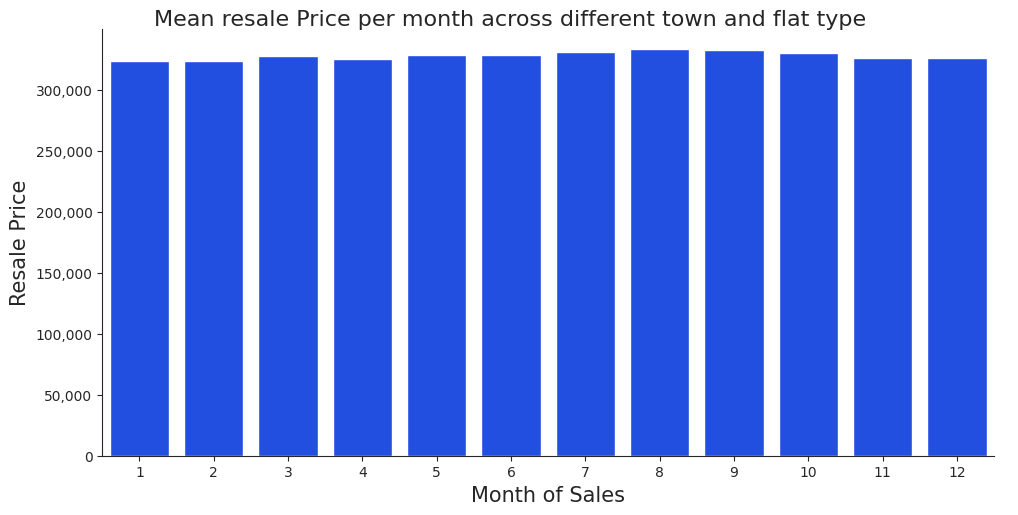

In [25]:
plt.clf()
plot_pricePerMonth_all(df)

In [18]:
# mean resale price per month across single town
def plot_pricePerMonth_single(df, room, twn):
    df_initial_preproc(df)
    df_query = df.query("flat_type == @room & town == @twn")
    sns.set_style("ticks")
    sns.set_palette("bright")
    # hue_order = ["1 ROOM", "2 ROOM", "3 ROOM", "4 ROOM", "5 ROOM","EXECUTIVE", "MULTI-GENERATION"]
    g = sns.catplot(
        data=df,
        x="month_of_sales",
        y="resale_price",
        kind="bar",
        height=5,
        aspect=1.5,
        errorbar=None,
    )
    g.fig.suptitle(
        f"Resale Price per month across {twn} and flat type: {room}",
        y=1.01,
        fontsize=15,
    )
    g.set(xlabel="Month of Sales", ylabel="Resale Price")
    g.ax.set_xlabel(
        g.ax.get_xlabel(), fontsize=14
    )  # Access and set x-axis label font size

    g.ax.set_ylabel(
        g.ax.get_ylabel(), fontsize=14
    )  # Access and set y-axis label font size

    # Format the y-axis tick labels to include commas using a lambda function
    formatter = mtick.FuncFormatter(lambda x, pos: f"{int(x):,}")
    g.ax.yaxis.set_major_formatter(formatter)
    plt.show()

<Figure size 640x480 with 0 Axes>

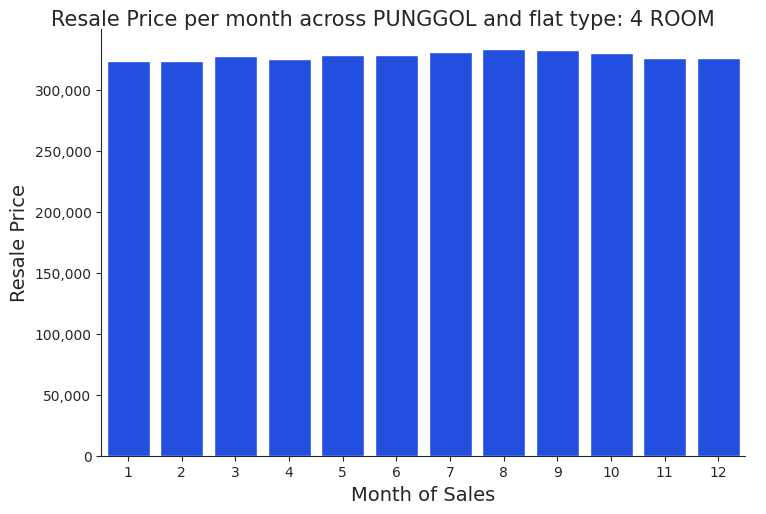

In [19]:
plt.clf()
plot_pricePerMonth_single(df, "4 ROOM", "PUNGGOL")

## Resale price over the years

In [20]:
# resale price trend across all town
def plot_priceTrend_all(df):
    df_initial_preproc(df)
    sns.set_style("ticks")
    sns.set_palette("bright")
    hue_order = [
        "1 ROOM",
        "2 ROOM",
        "3 ROOM",
        "4 ROOM",
        "5 ROOM",
        "EXECUTIVE",
        "MULTI-GENERATION",
    ]
    g = sns.relplot(
        data=df,
        x="month",
        y="resale_price",
        kind="line",
        height=5,
        aspect=2,
        palette="bright",
        errorbar=None,
        hue="flat_type",
        hue_order=hue_order,
    )
    g.fig.suptitle(f"Resale price trend across all town", y=1.01, fontsize=17)
    g.set(xlabel="Year", ylabel="Resale Price")

    g.ax.set_xlabel(
        g.ax.get_xlabel(), fontsize=16
    )  # Access and set x-axis label font size

    g.ax.set_ylabel(
        g.ax.get_ylabel(), fontsize=16
    )  # Access and set y-axis label font size

    plt.ticklabel_format(style="plain", axis="y")

    # Format the y-axis tick labels to include commas using a lambda function
    formatter = mtick.FuncFormatter(lambda x, pos: f"{int(x):,}")
    g.ax.yaxis.set_major_formatter(formatter)

    plt.show()

<Figure size 640x480 with 0 Axes>

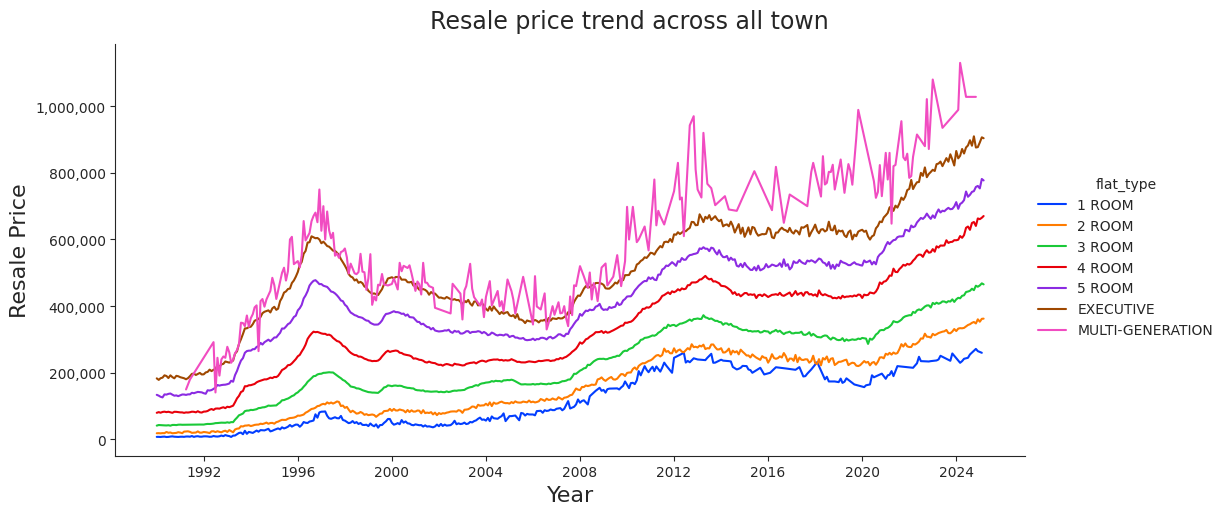

In [21]:
plt.clf()
plot_priceTrend_all(df)

In [22]:
# resale price trend across single town and flat type
def plot_priceTrend_single(df, room, twn):
    df_initial_preproc(df)
    df_query = df.query("flat_type == @room & town == @twn")
    sns.set_style("ticks")
    sns.set_palette("bright")
    g = sns.relplot(
        data=df_query,
        x="month",
        y="resale_price",
        kind="line",
        height=5,
        aspect=2,
        errorbar=None,
    )
    g.fig.suptitle(
        f"Resale price trend across {twn} and flat type: {room}", y=1.01, fontsize=16
    )
    g.set(xlabel="Year", ylabel="Resale Price")
    g.ax.set_xlabel(
        g.ax.get_xlabel(), fontsize=15
    )  # Access and set x-axis label font size

    g.ax.set_ylabel(
        g.ax.get_ylabel(), fontsize=15
    )  # Access and set y-axis label font size

    # Format the y-axis tick labels to include commas using a lambda function
    formatter = mtick.FuncFormatter(lambda x, pos: f"{int(x):,}")
    g.ax.yaxis.set_major_formatter(formatter)

    plt.show()

<Figure size 640x480 with 0 Axes>

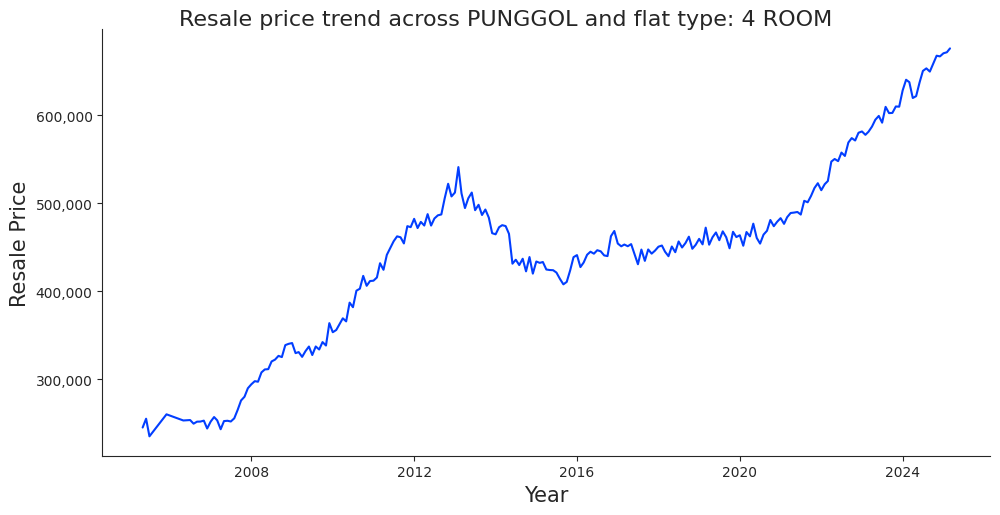

In [23]:
plt.clf()
plot_priceTrend_single(df, "4 ROOM", "PUNGGOL")

In [8]:
df = df_initial_preproc(df)

In [9]:
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,remaining_lease,year,year_of_sales,month_of_sales,price_per_sqm
0,1990-01-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977,9000.0,NaN,1990,1990,1,290.322581
1,1990-01-01,KALLANG/WHAMPOA,3 ROOM,44,BENDEMEER RD,04 TO 06,63.0,STANDARD,1981,31400.0,NaN,1990,1990,1,498.412698
2,1990-01-01,KALLANG/WHAMPOA,3 ROOM,20,ST. GEORGE'S RD,04 TO 06,67.0,NEW GENERATION,1984,66500.0,NaN,1990,1990,1,992.537313
3,1990-01-01,KALLANG/WHAMPOA,3 ROOM,14,KG ARANG RD,04 TO 06,103.0,NEW GENERATION,1984,77000.0,NaN,1990,1990,1,747.572816
4,1990-01-01,KALLANG/WHAMPOA,3 ROOM,46,OWEN RD,01 TO 03,68.0,NEW GENERATION,1982,58000.0,NaN,1990,1990,1,852.941176


In [30]:
df_query = df.query("flat_type == '4 ROOM' & town == 'PUNGGOL'")
df_last_resale_price = df_query.sort_index(ascending=False)
last_resale_price = df_last_resale_price.iloc[0]["resale_price"]
formatted_price = "{:,}".format(int(round(last_resale_price)))
formatted_price

'650,000'

In [32]:
def data_last_resale_price(df, room, twn):
    # df_initial_preproc(df)
    df_query = df.query("flat_type == @room & town == @twn")

    df_last_resale_price = df_query.sort_index(ascending=False)
    last_resale_price = df_last_resale_price.iloc[0]["resale_price"]

    formatted_price = "{:,}".format(int(round(last_resale_price)))

    return formatted_price

In [33]:
data_last_resale_price(df, "4 ROOM", "PUNGGOL")

'650,000'